<a href="https://colab.research.google.com/github/Arebu18/ArebMY/blob/main/ETL_%2B_DNN_STACKING_META_LEARNER_MLD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
===================================================================================
CLINICAL-GRADE MALARIA PARASITE DETECTION USING
ENSEMBLE TRANSFER LEARNING + DNN STACKING META-LEARNER
===================================================================================

OBJECTIVE:
-----------
This project implements an optimized ensemble transfer learning framework
for malaria parasite detection and classification from microscopic blood smear images.

MODELS USED:
--------------
1. VGG16
2. ResNet50
3. InceptionV3
4. MobileNetV2

ENSEMBLE METHOD:
----------------
- Base CNN models generate prediction probabilities
- A Deep Neural Network (DNN) acts as a meta-learner
- Final prediction comes from the DNN stacking classifier

TRAINING STRATEGY:
-------------------
Stage 1:
    Freeze all pretrained layers
    Train only custom classification head

Stage 2:
    Unfreeze EXACTLY last 20 layers
    Fine-tune using Adam optimizer

EVALUATION METRICS:
--------------------
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC
- Confusion Matrix

DATASET STRUCTURE:
-------------------
dataset/
    Parasitized/
    Uninfected/

RECOMMENDED DATASET:
---------------------
NIH Malaria Cell Images Dataset

===================================================================================
"""

# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =============================================================================
# CONFIGURATION
# =============================================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 10
NUM_CLASSES = 1

DATASET_PATH = "dataset"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/HDAproject/malariaarchive.zip"

In [ ]:
import zipfile
import os

# Destination folder after extraction
extract_path = "/content/malaria_dataset"

# Create folder if it does not exist
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
import os

# Define the base directory where you extracted the zip
base_path = '/content/malaria_dataset'

print("--- Root Folder Contents ---")
for root, dirs, files in os.walk(base_path):
    # This helps find the folder that actually contains 'Parasitized' and 'Uninfected'
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        print(f"FOUND DATASET AT: {root}")
        print(f"Subfolders: {dirs}")
        # Count a few files to make sure they aren't empty
        p_count = len(os.listdir(os.path.join(root, 'Parasitized')))
        u_count = len(os.listdir(os.path.join(root, 'Uninfected')))
        print(f"Images: {p_count} Parasitized, {u_count} Uninfected")

        # This is the path you should use for DATA_DIR in your model code
        DATA_DIR = root
        break

--- Root Folder Contents ---
FOUND DATASET AT: /content/malaria_dataset/cell_images
Subfolders: ['Uninfected', 'cell_images', 'Parasitized']
Images: 13780 Parasitized, 13780 Uninfected


In [ ]:
import os
import numpy as np

DATASET_PATH = "/content/malaria_dataset/cell_images"

image_paths = []
labels = []

# Only use actual class folders
VALID_CLASSES = ["Parasitized", "Uninfected"]

for class_name in VALID_CLASSES:

    class_path = os.path.join(DATASET_PATH, class_name)

    # Skip if folder does not exist
    if not os.path.exists(class_path):
        continue

    for img in os.listdir(class_path):

        full_path = os.path.join(class_path, img)

        # Ensure it is a file
        if os.path.isfile(full_path):

            image_paths.append(full_path)

            if class_name == "Parasitized":
                labels.append(1)

            else:
                labels.append(0)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total Images:", len(image_paths))
print("Total Labels:", len(labels))

Total Images: 27560
Total Labels: 27560


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np

# =============================================================================
# DATA PREPROCESSING
# =============================================================================

"""
70/30 TRAIN-TEST SPLIT
-----------------------
This ensures uncontaminated clinical evaluation.
"""

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.0,
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

# Load all image file paths manually for exact split
DATASET_PATH = "/content/malaria_dataset/cell_images"
image_paths = [] # Initialize image_paths as an empty list
labels = []

for class_name in ["Parasitized", "Uninfected"]:

    class_path = os.path.join(DATASET_PATH, class_name)

    for img in os.listdir(class_path):

        image_paths.append(os.path.join(class_path, img))

        if class_name == "Parasitized":
            labels.append(1)
        else:
            labels.append(0)

image_paths = np.array(image_paths)
labels = np.array(labels)

# EXACT 70/30 SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 19292
Testing Samples : 8268


In [ ]:
# =============================================================================
# CREATE DATA GENERATORS
# =============================================================================

import pandas as pd

# Redefine configuration variables as they were not found in the current scope
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_df = pd.DataFrame({
    "filename": X_train,
    "class": y_train.astype(str)
})

test_df = pd.DataFrame({
    "filename": X_test,
    "class": y_test.astype(str)
})

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 19290 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 2 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
# =============================================================================
# FUNCTION TO BUILD TRANSFER LEARNING MODEL
# =============================================================================

def build_transfer_model(base_model_name):

    """
    Builds a transfer learning model with:
    - Frozen pretrained layers
    - Custom classification head
    """

    if base_model_name == "VGG16":

        base_model = tf.keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )

    elif base_model_name == "ResNet50":

        base_model = tf.keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )

    elif base_model_name == "InceptionV3":

        base_model = tf.keras.applications.InceptionV3(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )

    elif base_model_name == "MobileNetV2":

        base_model = tf.keras.applications.MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )

    # Freeze all layers initially
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom classification head
    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu")(x)

    x = Dropout(0.5)(x)

    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)

    return model, base_model

In [ ]:
# =============================================================================
# TRAINING FUNCTION
# =============================================================================

def train_model(model, base_model, model_name):

    """
    TWO-STAGE FINE-TUNING
    ---------------------
    Stage 1:
        Frozen feature extractor

    Stage 2:
        Unfreeze EXACTLY last 20 layers
    """

    print(f"\n================ {model_name} ================")

    # =========================================================================
    # STAGE 1: TRAIN CUSTOM HEAD
    # =========================================================================

    print("\nStage 1: Frozen Feature Extraction")

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=EPOCHS_STAGE1
    )

    # =========================================================================
    # STAGE 2: FINE-TUNING LAST 20 LAYERS
    # =========================================================================

    print("\nStage 2: Fine-Tuning Last 20 Layers")


    for layer in base_model.layers[-20:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=EPOCHS_STAGE2
    )

    return model

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Add the missing configuration variables to ensure they are defined
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 10

# =============================================================================
# BUILD ALL BASE CNN MODELS
# =============================================================================

vgg_model, vgg_base = build_transfer_model("VGG16")

resnet_model, resnet_base = build_transfer_model("ResNet50")

inception_model, inception_base = build_transfer_model("InceptionV3")

mobilenet_model, mobilenet_base = build_transfer_model("MobileNetV2")

# =============================================================================
# TRAIN ALL MODELS
# =============================================================================

vgg_model = train_model(vgg_model, vgg_base, "VGG16")

resnet_model = train_model(resnet_model, resnet_base, "ResNet50")

inception_model = train_model(inception_model, inception_base, "InceptionV3")

mobilenet_model = train_model(mobilenet_model, mobilenet_base, "MobileNetV2")

# =============================================================================
# GENERATE PREDICTIONS FOR STACKING
# =============================================================================

"""
Each CNN produces probability predictions.
These predictions become input features for the DNN meta-learner.
"""

vgg_preds = vgg_model.predict(test_generator)

resnet_preds = resnet_model.predict(test_generator)

inception_preds = inception_model.predict(test_generator)

mobilenet_preds = mobilenet_model.predict(test_generator)

# Stack predictions horizontally
stacked_features = np.hstack([
    vgg_preds,
    resnet_preds,
    inception_preds,
    mobilenet_preds
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

================ VGG16 ================

Stage 1: Frozen Feature Extraction
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 169s 256ms/step - accuracy: 0.8054 - loss: 0.4358 - val_accuracy: 0.8849 - val_loss: 0.2931
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 140s 232ms/step - accuracy: 0.8905 - loss: 0.2826 - val_accuracy: 0.9098 - val_loss: 0.2341
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 140s 232ms/step - accuracy: 0.9041 - loss: 0.2453 - val_accuracy: 0.9113 - val_loss: 0.2224
Epoch 4/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 140s 232ms/step - accuracy: 0.9114 - loss: 0.2328 - val_accuracy: 0.9221 - val_loss: 0.2178
Epoch 5/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 140s 232ms/step - accuracy: 0.9120 - loss: 0.2264 - val_accuracy: 0.9242 - val_loss: 0.2060

Stage 2: Fine-Tuning Last 20 Layers
Epoch 1/10
603/603 ━━━━━━━━━━

In [ ]:
# =============================================================================
# BUILD DNN META-LEARNER
# =============================================================================

"""
DNN STACKING META-CLASSIFIER
-----------------------------
Learns how to combine CNN predictions intelligently.
"""

from tensorflow.keras.models import Sequential

meta_model = Sequential([

    Dense(64, activation="relu", input_shape=(4,)),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")

])

meta_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =============================================================================
# TRAIN META-LEARNER
# =============================================================================

meta_model.fit(
    stacked_features,
    y_test,
    epochs=15,
    batch_size=16,
    validation_split=0.2
)

# =============================================================================
# FINAL PREDICTIONS
# =============================================================================

final_probs = meta_model.predict(stacked_features)

final_preds = (final_probs > 0.5).astype(int)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


414/414 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9475 - loss: 0.1925 - val_accuracy: 0.9710 - val_loss: 0.1014
Epoch 2/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9642 - loss: 0.1299 - val_accuracy: 0.9722 - val_loss: 0.0990
Epoch 3/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9645 - loss: 0.1301 - val_accuracy: 0.9716 - val_loss: 0.1004
Epoch 4/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9640 - loss: 0.1262 - val_accuracy: 0.9728 - val_loss: 0.0993
Epoch 5/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9651 - loss: 0.1239 - val_accuracy: 0.9716 - val_loss: 0.0966
Epoch 6/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9640 - loss: 0.1233 - val_accuracy: 0.9722 - val_loss: 0.0958
Epoch 7/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.1201 - val_accuracy: 0.9722 - val_loss: 0.0945
Epoch 8/15
414/414 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9633 - loss: 0.1227 - val_accuracy: 0.9722 - val_

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =============================================================================
# EVALUATION METRICS
# =============================================================================

accuracy = accuracy_score(y_test, final_preds)

precision = precision_score(y_test, final_preds)

recall = recall_score(y_test, final_preds)

f1 = f1_score(y_test, final_preds)

auc = roc_auc_score(y_test, final_probs)

# =============================================================================
# DISPLAY RESULTS
# =============================================================================

print("\n===================================================")
print("CLINICAL-GRADE MALARIA DETECTION RESULTS")
print("===================================================")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1-Score : {f1:.4f}")

print(f"AUC-ROC  : {auc:.4f}")


CLINICAL-GRADE MALARIA DETECTION RESULTS
Accuracy : 0.9670
Precision: 0.9703
Recall   : 0.9635
F1-Score : 0.9669
AUC-ROC  : 0.9928



Confusion Matrix
[[4012  122]
 [ 151 3983]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4134
           1       0.97      0.96      0.97      4134

    accuracy                           0.97      8268
   macro avg       0.97      0.97      0.97      8268
weighted avg       0.97      0.97      0.97      8268



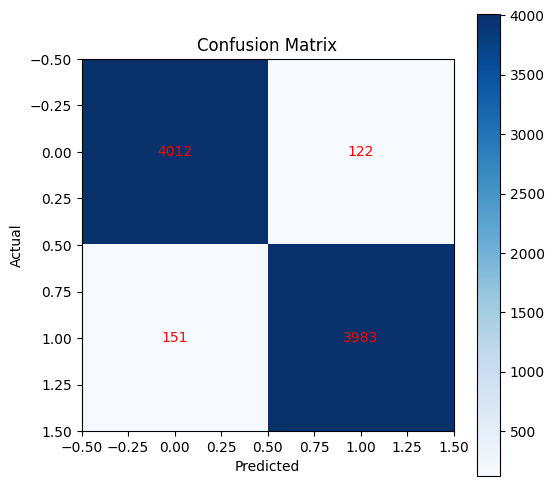


All models saved successfully.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, final_preds)

print("\nConfusion Matrix")

print(cm)

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

print("\nClassification Report")

print(classification_report(y_test, final_preds))

# =============================================================================
# PLOT CONFUSION MATRIX
# =============================================================================

plt.figure(figsize=(6, 6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="red"
        )

plt.show()

# =============================================================================
# SAVE MODELS
# =============================================================================

vgg_model.save("vgg16_malaria_model.h5")

resnet_model.save("resnet50_malaria_model.h5")

inception_model.save("inceptionv3_malaria_model.h5")

mobilenet_model.save("mobilenetv2_malaria_model.h5")

meta_model.save("dnn_meta_learner.h5")

print("\nAll models saved successfully.")

# =============================================================================
# END OF PROJECT
# =============================================================================


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

import seaborn as sns

In [ ]:
# Predict probabilities
y_prob = final_probs

# Convert probabilities to binary predictions
y_pred = final_preds.flatten()

# True labels
y_true = y_test

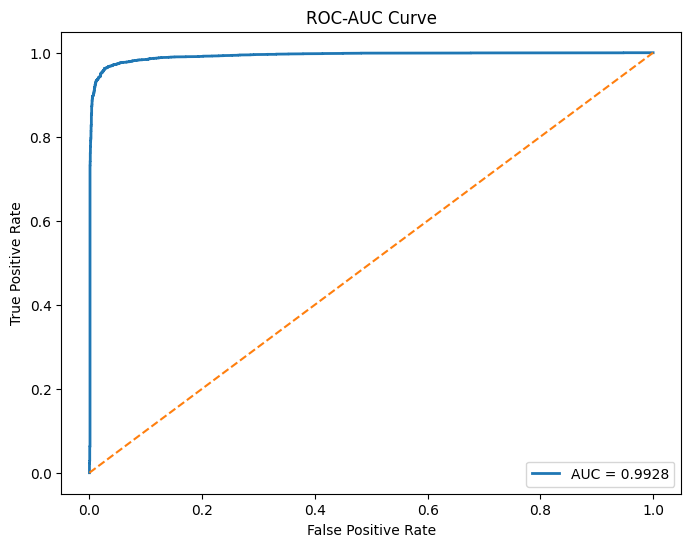

AUC Score: 0.9927554231268938


In [ ]:
# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend(loc="lower right")

plt.show()

print("AUC Score:", roc_auc)

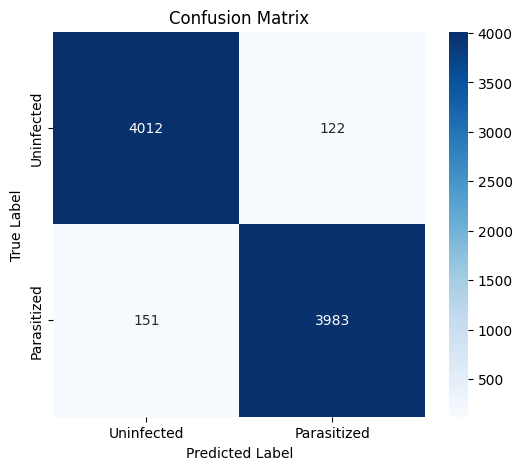

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Uninfected", "Parasitized"],
    yticklabels=["Uninfected", "Parasitized"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

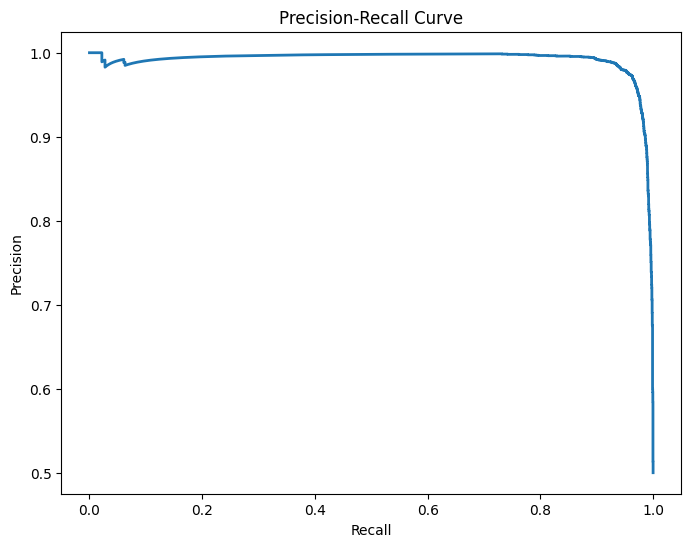

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4134
           1       0.97      0.96      0.97      4134

    accuracy                           0.97      8268
   macro avg       0.97      0.97      0.97      8268
weighted avg       0.97      0.97      0.97      8268



In [ ]:
import tensorflow as tf
import cv2

In [ ]:
last_conv_layer_name = "block5_conv3"

In [ ]:
last_conv_layer_name = "block5_conv3" # Corrected for VGG16 model

In [ ]:
img_path = image_paths[0]

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [ ]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap # Removed .numpy() as heatmap is already a numpy array

In [ ]:
last_conv_layer_name = "block5_conv3" # Ensure correct layer name for VGG16
heatmap = make_gradcam_heatmap(
    img_array,
    vgg_model,
    last_conv_layer_name
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


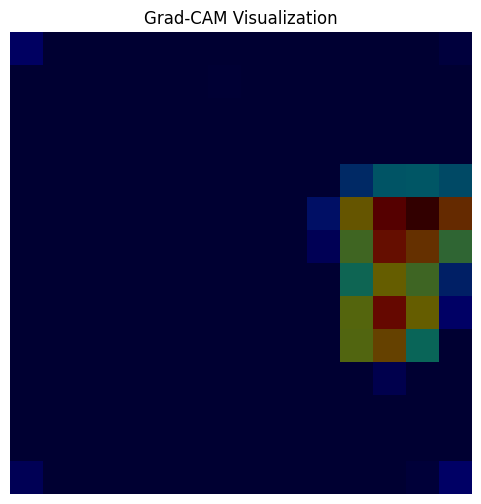

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.imshow(heatmap, cmap='jet', alpha=0.4)

plt.title("Grad-CAM Visualization")

plt.axis("off")

plt.show()